# DPO — 不训奖励模型的偏好优化实验

验证 `dpo.tex` 中的核心结论：

1. **同一份数据，省掉两个组件**：同一份偏好对上，DPO 不训奖励模型、不跑 PPO，真实分数达到与第 11 章 RLHF 管线相当的水平；
2. **隐式奖励，同一个病**：DPO 等价于在拟合一个隐式奖励 $\hat{r}(y)=\beta\log\frac{\pi(y)}{\pi_{\mathrm{ref}}(y)}$——它在偏好数据覆盖区外同样单调外推，与第 11 章的显式奖励模型犯同一个错；
3. **会松动的锚**：β 越小漂移越快；即使甜点 β，随训练加长策略也会缓慢漂出覆盖区——训练时长是 DPO 的隐藏超参，early stopping 不是可选项。

任务与第 11 章完全相同（词表 24、序列长 12、强调 token 凹形加分），偏好数据同样由 SFT 采样并按噪声 BT 模型标注。对照组复刻第 11 章管线：奖励模型 + PPO（β=0.5）。

输出图：
- `fig1_dpo_vs_rlhf.pdf`
- `fig2_implicit_reward.pdf`
- `fig3_beta_anchor.pdf`

预计运行时间：GPU 约 12 分钟；CPU 约 1 小时（3 seeds）。

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

BLUE  = '#2166AC'
RED   = '#D6604D'
GRAY  = '#808080'
FIGSIZE = (7.2, 4.8)
OUTDIR  = '.'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

VOCAB   = 24
BOS     = VOCAB
SEQ_LEN = 12
E_TOKEN = 12
T_BASE  = 1.5
D_MODEL = 64
SEEDS   = (42, 43, 44)

TOKEN_VALUES   = np.linspace(-1.0, 1.0, VOCAB)
TOKEN_VALUES_T = torch.tensor(TOKEN_VALUES, dtype=torch.float32, device=DEVICE)
PEAK_C     = 3
BONUS_UP   = 0.3
BONUS_DOWN = 0.6


def bonus(count):
    up = BONUS_UP * torch.clamp(count.float(), max=PEAK_C)
    down = BONUS_DOWN * torch.clamp(count.float() - PEAK_C, min=0)
    return up - down


def true_score(seqs):
    """Ground-truth quality: mean token value + concave emphasis bonus."""
    vals = TOKEN_VALUES_T[seqs].mean(dim=1)
    return vals + bonus((seqs == E_TOKEN).sum(dim=1))


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)


def style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


print(f'Device: {DEVICE}')

Device: cuda


In [2]:
class TinyLM(nn.Module):
    """Char-level causal Transformer LM (~120k params), same as chapter 11."""

    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB + 1, D_MODEL)
        self.pos = nn.Embedding(SEQ_LEN + 1, D_MODEL)
        layer = nn.TransformerEncoderLayer(D_MODEL, 4, 128, batch_first=True,
                                           dropout=0.0, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, 2, enable_nested_tensor=False)
        self.head = nn.Linear(D_MODEL, VOCAB)
        mask = torch.triu(torch.full((SEQ_LEN + 1, SEQ_LEN + 1), float('-inf')), 1)
        self.register_buffer('mask', mask)

    def logits(self, inp):
        L = inp.size(1)
        h = self.emb(inp) + self.pos(torch.arange(L, device=inp.device))
        h = self.encoder(h, mask=self.mask[:L, :L])
        return self.head(h)

    @torch.no_grad()
    def generate(self, batch):
        inp = torch.full((batch, 1), BOS, dtype=torch.long, device=DEVICE)
        for _ in range(SEQ_LEN):
            logits = self.logits(inp)[:, -1]
            nxt = torch.multinomial(F.softmax(logits, dim=-1), 1)
            inp = torch.cat([inp, nxt], dim=1)
        return inp[:, 1:]

    def log_probs(self, seqs):
        inp = torch.cat([torch.full((seqs.size(0), 1), BOS, dtype=torch.long,
                                    device=DEVICE), seqs[:, :-1]], dim=1)
        logits = self.logits(inp)
        return torch.log_softmax(logits, dim=-1).gather(2, seqs.unsqueeze(2)).squeeze(2)


class RewardModel(nn.Module):
    """Chapter-11 explicit reward model, used only by the RLHF baseline."""

    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB, D_MODEL)
        self.net = nn.Sequential(nn.Linear(D_MODEL, D_MODEL), nn.ReLU(),
                                 nn.Linear(D_MODEL, 1))
        self.mu = 0.0
        self.sigma = 1.0

    def raw(self, seqs):
        return self.net(self.emb(seqs).mean(dim=1)).squeeze(1)

    def forward(self, seqs):
        return (self.raw(seqs) - self.mu) / self.sigma

    @torch.no_grad()
    def calibrate(self, base_seqs):
        r = self.raw(base_seqs)
        self.mu = r.mean().item()
        self.sigma = r.std().item() + 1e-8

In [3]:
def sample_base_corpus(n):
    probs = F.softmax(torch.tensor(TOKEN_VALUES / T_BASE), dim=0).numpy()
    return torch.tensor(np.random.choice(VOCAB, size=(n, SEQ_LEN), p=probs),
                        dtype=torch.long, device=DEVICE)


def train_sft(steps=800, batch=256, lr=3e-3):
    lm = TinyLM().to(DEVICE)
    opt = torch.optim.Adam(lm.parameters(), lr=lr)
    for _ in range(steps):
        loss = -lm.log_probs(sample_base_corpus(batch)).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    return lm


def make_pref_pairs(lm, n_pairs, noise=0.1):
    a = lm.generate(n_pairs)
    b = lm.generate(n_pairs)
    sa, sb = true_score(a), true_score(b)
    a_wins = torch.bernoulli(torch.sigmoid((sa - sb) / noise)).bool()
    return (torch.where(a_wins.unsqueeze(1), a, b),
            torch.where(a_wins.unsqueeze(1), b, a))


def train_rm(winners, losers, base, steps=600, batch=128, lr=1e-3):
    rm = RewardModel().to(DEVICE)
    opt = torch.optim.Adam(rm.parameters(), lr=lr)
    n = winners.size(0)
    for _ in range(steps):
        idx = torch.randint(0, n, (batch,), device=DEVICE)
        loss = -F.logsigmoid(rm.raw(winners[idx]) - rm.raw(losers[idx])).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    rm.calibrate(base)
    return rm


def ppo_finetune(sft, rm, beta, iters=150, batch=256, k_epochs=4, mb=64,
                 clip=0.2, lr=3e-5):
    """Chapter-11 RLHF baseline: PPO-clip against the explicit reward model."""
    policy = TinyLM().to(DEVICE)
    policy.load_state_dict(sft.state_dict())
    ref = TinyLM().to(DEVICE)
    ref.load_state_dict(sft.state_dict())
    ref.eval()
    opt = torch.optim.Adam(policy.parameters(), lr=lr)
    truth_hist = []
    for it in range(iters):
        with torch.no_grad():
            seqs = policy.generate(batch)
            lp_old = policy.log_probs(seqs)
            lp_ref = ref.log_probs(seqs)
            shaped = rm(seqs) - beta * (lp_old - lp_ref).sum(dim=1)
            adv = (shaped - shaped.mean()) / (shaped.std() + 1e-8)
        for _ in range(k_epochs):
            perm = torch.randperm(batch, device=DEVICE)
            for s in range(0, batch, mb):
                idx = perm[s:s + mb]
                lp_new = policy.log_probs(seqs[idx])
                ratio = torch.exp((lp_new - lp_old[idx]).sum(dim=1))
                s1 = ratio * adv[idx]
                s2 = torch.clamp(ratio, 1 - clip, 1 + clip) * adv[idx]
                loss = -torch.min(s1, s2).mean()
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
                opt.step()
        truth_hist.append(true_score(seqs).mean().item())
    return truth_hist

In [4]:
def train_dpo(sft, winners, losers, beta, steps=3000, batch=128, lr=1e-4,
              eval_every=50):
    """Direct Preference Optimization on fixed preference pairs.

    No reward model, no sampling during training; the policy is evaluated
    by generation only for logging.
    """
    policy = TinyLM().to(DEVICE)
    policy.load_state_dict(sft.state_dict())
    ref = TinyLM().to(DEVICE)
    ref.load_state_dict(sft.state_dict())
    ref.eval()
    opt = torch.optim.Adam(policy.parameters(), lr=lr)
    n = winners.size(0)
    history = {'step': [], 'truth': [], 'count_e': [], 'kl': []}
    for step in range(1, steps + 1):
        idx = torch.randint(0, n, (batch,), device=DEVICE)
        w, l = winners[idx], losers[idx]
        with torch.no_grad():
            ref_w = ref.log_probs(w).sum(1)
            ref_l = ref.log_probs(l).sum(1)
        pol_w = policy.log_probs(w).sum(1)
        pol_l = policy.log_probs(l).sum(1)
        margin = (pol_w - ref_w) - (pol_l - ref_l)
        loss = -F.logsigmoid(beta * margin).mean()
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        opt.step()
        if step % eval_every == 0:
            with torch.no_grad():
                gen = policy.generate(512)
                history['step'].append(step)
                history['truth'].append(true_score(gen).mean().item())
                history['count_e'].append(
                    (gen == E_TOKEN).float().sum(dim=1).mean().item())
                history['kl'].append(
                    (policy.log_probs(gen) - ref.log_probs(gen)).sum(1).mean().item())
    return policy, ref, history


@torch.no_grad()
def implicit_reward_curve(policy, ref, beta, n=512):
    """Implicit reward beta*log(pi/pi_ref) for sequences with exactly c emphasis tokens."""
    rows = []
    for c in range(SEQ_LEN + 1):
        seqs = sample_base_corpus(n)
        seqs = seqs.masked_fill(seqs == E_TOKEN, E_TOKEN + 1)
        for i in range(n):
            pos = torch.randperm(SEQ_LEN, device=DEVICE)[:c]
            seqs[i, pos] = E_TOKEN
        imp = beta * (policy.log_probs(seqs).sum(1) - ref.log_probs(seqs).sum(1))
        rows.append((imp.mean().item(), true_score(seqs).mean().item()))
    return rows

In [5]:
print('=== SFT + preference data, per seed (same recipe as chapter 11) ===')
runs = {}
for seed in SEEDS:
    set_seed(seed)
    sft = train_sft()
    base = sft.generate(2000)
    winners, losers = make_pref_pairs(sft, 4000)
    runs[seed] = {'sft': sft, 'base': base,
                  'winners': winners, 'losers': losers}
    print(f'  seed {seed}: base truth {true_score(base).mean():+.3f}')

=== SFT + preference data, per seed (same recipe as chapter 11) ===


  seed 42: base truth +0.389


  seed 43: base truth +0.384


  seed 44: base truth +0.386


---
## Figure 1 — DPO vs RLHF：同一份偏好数据

对照组是第 11 章的完整管线：先训奖励模型（BT + 白化），再跑带 KL 惩罚的 PPO（β=0.5，最终真实分数约 +0.84）。DPO 组在**同一份 4000 偏好对**上直接优化策略，不训奖励模型、不做任何采样训练。β=2.0 的 DPO 在约 1000–2000 步处达到与 RLHF 相当的真实分数（约 +0.8 ~ +1.0）——两条通往同一目标的路，DPO 省掉了两个组件（3 seeds，阴影为 $\pm 1\sigma$）。

In [6]:
print('=== Experiment 1: DPO (beta=2.0) vs the chapter-11 RLHF pipeline ===')
dpo_hists = {}
rlhf_finals = []
for seed in SEEDS:
    set_seed(seed + 2000)
    r = runs[seed]
    _, _, dpo_hists[(seed, 2.0)] = train_dpo(r['sft'], r['winners'], r['losers'],
                                             beta=2.0)
    h = dpo_hists[(seed, 2.0)]
    set_seed(seed + 5000)
    rm = train_rm(r['winners'], r['losers'], r['base'])
    rlhf_truth = ppo_finetune(r['sft'], rm, beta=0.5)
    rlhf_finals.append(np.mean(rlhf_truth[-10:]))
    print(f"  seed {seed}: DPO peak {max(h['truth']):+.3f} | "
          f"DPO final {h['truth'][-1]:+.3f} | RLHF final {rlhf_finals[-1]:+.3f}")
rlhf_mean = float(np.mean(rlhf_finals))
base_truth = float(np.mean([true_score(runs[s]['base']).mean().item()
                            for s in SEEDS]))
print(f'RLHF reference (mean of final-10): {rlhf_mean:+.3f} | SFT: {base_truth:+.3f}')

=== Experiment 1: DPO (beta=2.0) vs the chapter-11 RLHF pipeline ===


  seed 42: DPO peak +0.942 | DPO final +0.588 | RLHF final +0.850


  seed 43: DPO peak +0.989 | DPO final +0.924 | RLHF final +0.846


  seed 44: DPO peak +1.045 | DPO final +1.035 | RLHF final +0.811
RLHF reference (mean of final-10): +0.835 | SFT: +0.386


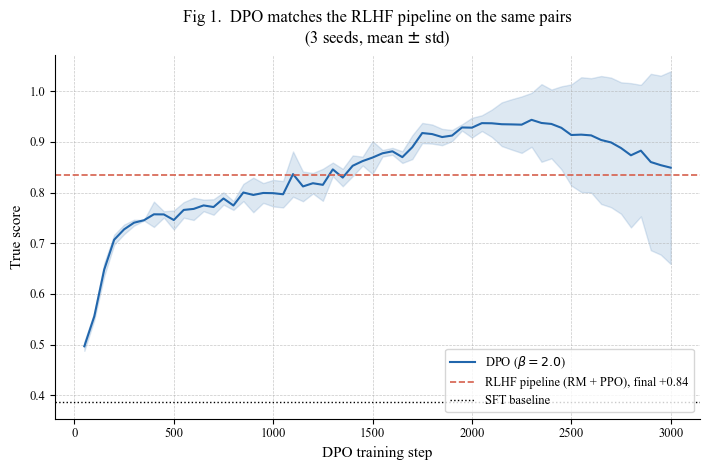

Saved fig1_dpo_vs_rlhf.pdf


In [7]:
def stack(key, beta):
    return np.array([dpo_hists[(seed, beta)][key] for seed in SEEDS])

fig, ax = plt.subplots(figsize=FIGSIZE)
steps = np.array(dpo_hists[(SEEDS[0], 2.0)]['step'])

truth = stack('truth', 2.0)
ax.plot(steps, truth.mean(0), color=BLUE, linewidth=1.5, label='DPO ($\\beta=2.0$)')
ax.fill_between(steps, truth.mean(0) - truth.std(0), truth.mean(0) + truth.std(0),
                color=BLUE, alpha=0.15)
ax.axhline(rlhf_mean, color=RED, linestyle='--', linewidth=1.2,
           label=f'RLHF pipeline (RM + PPO), final {rlhf_mean:+.2f}')
ax.axhline(base_truth, color='black', linestyle=':', linewidth=1.0,
           label='SFT baseline')

style_axes(ax)
ax.set_xlabel('DPO training step')
ax.set_ylabel('True score')
ax.set_title('Fig 1.  DPO matches the RLHF pipeline on the same pairs\n'
             '(3 seeds, mean $\\pm$ std)', pad=8)
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig1_dpo_vs_rlhf.pdf', bbox_inches='tight')
plt.show()
print('Saved fig1_dpo_vs_rlhf.pdf')

---
## Figure 2 — 隐式奖励：同一个病

DPO 的损失等价于在拟合隐式奖励 $\hat{r}(y)=\beta\log\frac{\pi(y)}{\pi_{\mathrm{ref}}(y)}$。把训练后策略（本图取 β=0.1，即 Figure 3 中崩塌的那组）的隐式奖励按强调 token 数 $c_E$ 分组测量：覆盖区内它与真实分数同向（学到了偏好），覆盖区外真实分数崩坏、隐式奖励却继续单调上扬——与第 11 章显式奖励模型的外推曲线（该章 Figure 1 右）如出一辙。**绕开了奖励模型这个组件，绕不开「奖励只在数据覆盖区内可信」这个事实**（3 seeds，阴影为 $\pm 1\sigma$）。

In [8]:
print('=== Experiment 2: DPO with beta=0.1, then measure the implicit reward ===')
imp_curves = []
for seed in SEEDS:
    set_seed(seed + 3000)
    r = runs[seed]
    policy, ref, dpo_hists[(seed, 0.1)] = train_dpo(r['sft'], r['winners'],
                                                    r['losers'], beta=0.1)
    h = dpo_hists[(seed, 0.1)]
    set_seed(seed + 4000)
    imp_curves.append(implicit_reward_curve(policy, ref, beta=0.1))
    print(f"  seed {seed}: final truth {h['truth'][-1]:+.3f} | "
          f"final c_E {h['count_e'][-1]:.1f} | final KL {h['kl'][-1]:.1f}")
imp_curves = np.array(imp_curves)  # (seeds, c, [implicit, true])

=== Experiment 2: DPO with beta=0.1, then measure the implicit reward ===


  seed 42: final truth -4.457 | final c_E 12.0 | final KL 38.0


  seed 43: final truth -4.230 | final c_E 11.6 | final KL 37.2


  seed 44: final truth -2.821 | final c_E 9.5 | final KL 29.6


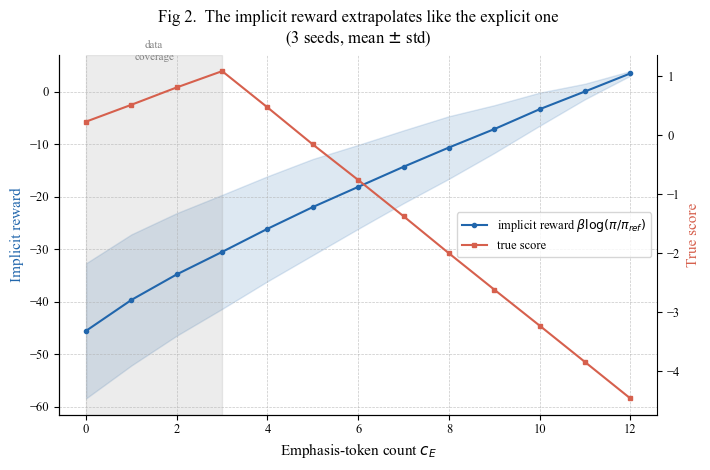

Saved fig2_implicit_reward.pdf


In [9]:
fig, ax = plt.subplots(figsize=FIGSIZE)
cs = np.arange(SEQ_LEN + 1)

imp_mu, imp_sd = imp_curves[:, :, 0].mean(0), imp_curves[:, :, 0].std(0)
ax.plot(cs, imp_mu, color=BLUE, marker='o', markersize=3, linewidth=1.5,
        label='implicit reward $\\beta\\log(\\pi/\\pi_{ref})$')
ax.fill_between(cs, imp_mu - imp_sd, imp_mu + imp_sd, color=BLUE, alpha=0.15)
ax.set_ylabel('Implicit reward', color=BLUE)
ax.set_xlabel('Emphasis-token count $c_E$')

ax2 = ax.twinx()
ax2.plot(cs, imp_curves[0, :, 1], color=RED, marker='s', markersize=3,
         linewidth=1.5, label='true score')
ax2.set_ylabel('True score', color=RED)

ax.axvspan(0, PEAK_C, color=GRAY, alpha=0.15)
ax.text(PEAK_C / 2, ax.get_ylim()[1] * 0.86, 'data\ncoverage',
        ha='center', fontsize=8, color=GRAY)
style_axes(ax)
ax2.spines['top'].set_visible(False)
ax.set_title('Fig 2.  The implicit reward extrapolates like the explicit one\n'
             '(3 seeds, mean $\\pm$ std)', pad=8)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='center right')
fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig2_implicit_reward.pdf', bbox_inches='tight')
plt.show()
print('Saved fig2_implicit_reward.pdf')

---
## Figure 3 — β 与训练时长：会松动的锚

DPO 没有显式的 KL 惩罚项，β 通过隐式奖励的定义扮演锚的角色——但这个锚是**软**的：损失只要还没饱和，就持续放大 $\log\pi/\pi_{\mathrm{ref}}$ 的差距。β=0.1 在几百步内就把生成分布推出覆盖区（$c_E \to 12$，真实分数崩塌）；β=0.5 崩得慢一些但同样崩；β=2.0 先到甜点（约 +0.9），随后也开始缓慢漂移。DPO 从不采样自己的生成，token 级的泛化偏移照样把它带出数据覆盖区——**β 和训练步数共同决定漂移距离，early stopping 是 DPO 的隐藏超参**（3 seeds，阴影为 $\pm 1\sigma$）。

In [10]:
print('=== Experiment 3: beta sweep (0.5 remaining; 0.1 and 2.0 reused) ===')
for seed in SEEDS:
    set_seed(seed + 6000)
    r = runs[seed]
    _, _, dpo_hists[(seed, 0.5)] = train_dpo(r['sft'], r['winners'], r['losers'],
                                             beta=0.5)
for beta in (0.1, 0.5, 2.0):
    truths = np.array([dpo_hists[(s, beta)]['truth'][-1] for s in SEEDS])
    ces = np.array([dpo_hists[(s, beta)]['count_e'][-1] for s in SEEDS])
    print(f'  beta {beta}: final truth {truths.mean():+.3f} ± {truths.std():.3f} | '
          f'final c_E {ces.mean():.1f}')

=== Experiment 3: beta sweep (0.5 remaining; 0.1 and 2.0 reused) ===


  beta 0.1: final truth -3.836 ± 0.723 | final c_E 11.0
  beta 0.5: final truth -4.050 ± 0.295 | final c_E 11.4
  beta 2.0: final truth +0.849 ± 0.190 | final c_E 3.4


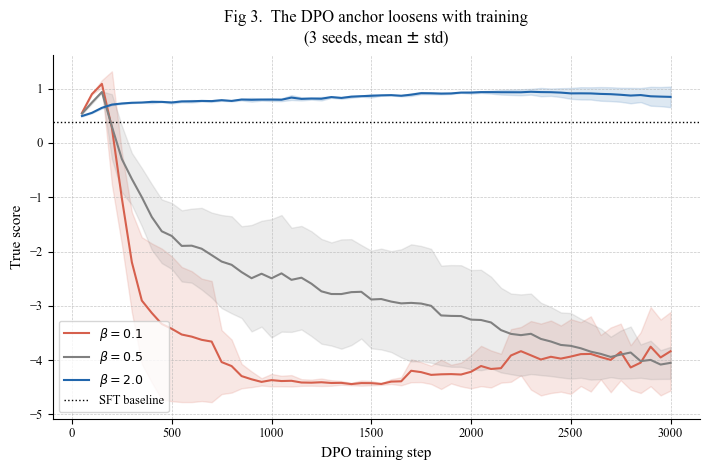

Saved fig3_beta_anchor.pdf


In [11]:
fig, ax = plt.subplots(figsize=FIGSIZE)
steps = np.array(dpo_hists[(SEEDS[0], 2.0)]['step'])

for beta, color, label in [(0.1, RED, r'$\beta=0.1$'),
                           (0.5, GRAY, r'$\beta=0.5$'),
                           (2.0, BLUE, r'$\beta=2.0$')]:
    truth = stack('truth', beta)
    ax.plot(steps, truth.mean(0), color=color, linewidth=1.5, label=label)
    ax.fill_between(steps, truth.mean(0) - truth.std(0),
                    truth.mean(0) + truth.std(0), color=color, alpha=0.15)
ax.axhline(base_truth, color='black', linestyle=':', linewidth=1.0,
           label='SFT baseline')

style_axes(ax)
ax.set_xlabel('DPO training step')
ax.set_ylabel('True score')
ax.set_title('Fig 3.  The DPO anchor loosens with training\n'
             '(3 seeds, mean $\\pm$ std)', pad=8)
ax.legend(loc='lower left')
fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig3_beta_anchor.pdf', bbox_inches='tight')
plt.show()
print('Saved fig3_beta_anchor.pdf')

## 小结

- **DPO 是 RLHF 的解析捷径**：KL 正则的奖励最大化有闭式最优策略，反解出隐式奖励代入 BT 似然，奖励模型和 PPO 就都不需要了——同一份偏好数据，同样的最终质量（Figure 1）；
- **省组件不省病**：隐式奖励在数据覆盖区外与显式奖励模型一样单调外推（Figure 2）——第 11 章的教训原封不动地适用于 DPO；
- **锚是软的**：DPO 没有硬 KL 约束，β 只是减速带；即使不采样，token 级泛化也会把生成分布推出覆盖区——β 过小快崩、适中慢漂，训练步数必须当超参对待（Figure 3）；
- **两章合起来的结论**：从 RLHF 到 DPO，变的是实现路径，不变的是「偏好数据的覆盖区决定可优化的边界」。下一章 GRPO/RLVR 换一种思路——用可验证的规则奖励，让「奖励被击穿」从根上不可能。